## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import time

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Divisão e avaliação
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, roc_curve,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregar e Preparar Dados

In [2]:
df = pd.read_csv('urldata_features.csv')

# Separar features e target
colunas_excluir = ['domain', 'ranking', 'label']
X = df.drop(columns=colunas_excluir)
y = df['label']

# Divisão 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features  : {X.shape[1]} colunas')
print(f'Treino    : {X_train.shape[0]:,} instâncias (80%)')
print(f'Teste     : {X_test.shape[0]:,} instâncias (20%)')

Features  : 21 colunas
Treino    : 76,728 instâncias (80%)
Teste     : 19,183 instâncias (20%)


## 3. Treino de Todos os Modelos

In [3]:
modelos = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=10000, solver='lbfgs', random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm='ball_tree'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='linear', random_state=42, probability=True, max_iter=1000)
}

resultados = {}

print(f'  {"Modelo":<22}  {"Accuracy":>9}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"AUC":>8}  {"Tempo":>7}')
print('  ' + '-' * 82)

for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempo = time.time() - inicio

    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'auc': auc, 'tempo': tempo
    }

    print(f'  {nome:<22}  {acc:>9.4f}  {prec:>10.4f}  {rec:>8.4f}  '
          f'{f1:>8.4f}  {auc:>8.4f}  {tempo:>5.1f}s')

print('\nTreino de todos os modelos concluído!')

  Modelo                   Accuracy   Precision    Recall        F1       AUC    Tempo
  ----------------------------------------------------------------------------------
  Random Forest              0.9468      0.9546    0.9382    0.9463    0.9879    3.5s
  Decision Tree              0.9200      0.9204    0.9193    0.9198    0.9202    1.4s
  Logistic Regression        0.8410      0.8577    0.8172    0.8370    0.9247   12.4s
  Naive Bayes                0.7860      0.9338    0.6152    0.7417    0.9105    0.1s
  KNN                        0.8990      0.9126    0.8823    0.8972    0.9534    0.5s
  Gradient Boosting          0.9066      0.9225    0.8876    0.9047    0.9687   31.9s


C:\Users\kyryl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  SVM                        0.6678      0.9620    0.3486    0.5118    0.2594   27.2s

Treino de todos os modelos concluído!


## 4. Tabela Comparativa

In [4]:
# Construir DataFrame de resultados
df_resultados = pd.DataFrame([
    {
        'Algoritmo'   : nome,
        'Accuracy'    : f"{r['accuracy']*100:.2f}%",
        'Precision'   : f"{r['precision']*100:.2f}%",
        'Recall'      : f"{r['recall']*100:.2f}%",
        'F1-Score'    : f"{r['f1']*100:.2f}%",
        'AUC-ROC'     : f"{r['auc']*100:.2f}%",
        'Tempo Treino': f"{r['tempo']:.1f}s",
    }
    for nome, r in resultados.items()
])

# Ordenar por F1-Score
df_resultados = df_resultados.sort_values(
    'F1-Score', ascending=False
).reset_index(drop=True)

print('Tabela Comparativa — Ordenada por F1-Score (decrescente):\n')
print(df_resultados.to_string(index=False))

Tabela Comparativa — Ordenada por F1-Score (decrescente):

          Algoritmo Accuracy Precision Recall F1-Score AUC-ROC Tempo Treino
      Random Forest   94.68%    95.46% 93.82%   94.63%  98.79%         3.5s
      Decision Tree   92.00%    92.04% 91.93%   91.98%  92.02%         1.4s
  Gradient Boosting   90.66%    92.25% 88.76%   90.47%  96.87%        31.9s
                KNN   89.90%    91.26% 88.23%   89.72%  95.34%         0.5s
Logistic Regression   84.10%    85.77% 81.72%   83.70%  92.47%        12.4s
        Naive Bayes   78.60%    93.38% 61.52%   74.17%  91.05%         0.1s
                SVM   66.78%    96.20% 34.86%   51.18%  25.94%        27.2s


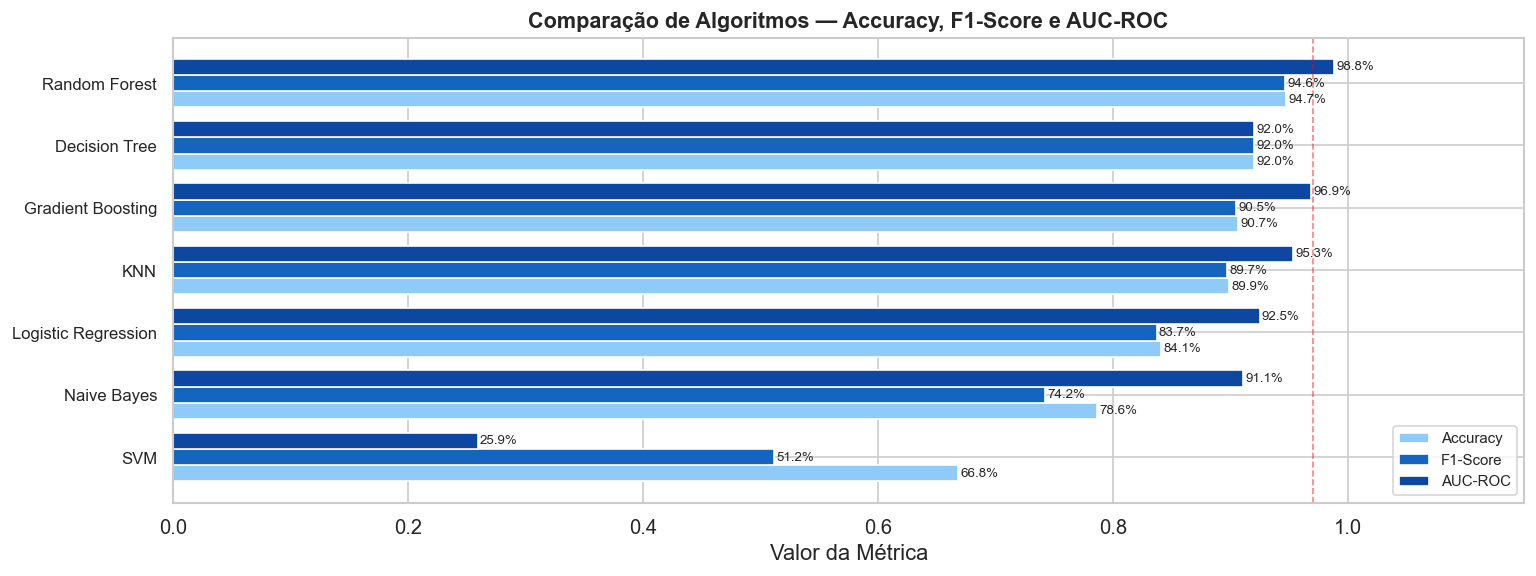

In [5]:
# Gráfico comparativo de F1-Score
nomes   = [r for r in resultados]
f1s     = [resultados[r]['f1'] for r in nomes]
aucs    = [resultados[r]['auc'] for r in nomes]
accs    = [resultados[r]['accuracy'] for r in nomes]

# Ordenar por F1
ordem = sorted(range(len(f1s)), key=lambda i: f1s[i])
nomes_ord = [nomes[i] for i in ordem]
f1s_ord   = [f1s[i]   for i in ordem]
aucs_ord  = [aucs[i]  for i in ordem]
accs_ord  = [accs[i]  for i in ordem]

x = np.arange(len(nomes_ord))
w = 0.26

fig, ax = plt.subplots(figsize=(13, 5))
bars_acc = ax.barh(x - w, accs_ord,  w, label='Accuracy',  color='#90caf9', edgecolor='white')
bars_f1  = ax.barh(x,     f1s_ord,   w, label='F1-Score',  color='#1565c0', edgecolor='white')
bars_auc = ax.barh(x + w, aucs_ord,  w, label='AUC-ROC',   color='#0d47a1', edgecolor='white')

for bars in [bars_acc, bars_f1, bars_auc]:
    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width()*100:.1f}%', va='center', fontsize=8)

ax.set_yticks(x)
ax.set_yticklabels(nomes_ord, fontsize=10)
ax.set_xlabel('Valor da Métrica')
ax.set_xlim(0, 1.15)
ax.set_title('Comparação de Algoritmos — Accuracy, F1-Score e AUC-ROC',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axvline(x=0.97, color='red', linestyle='--', linewidth=1, alpha=0.5,
           label='Referência literatura (97%)')
plt.tight_layout()
plt.savefig('fig6_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise Detalhada — Random Forest

Com base na tabela comparativa, procedemos à análise detalhada do modelo com melhor desempenho.

### 5.1 Matriz de Confusão

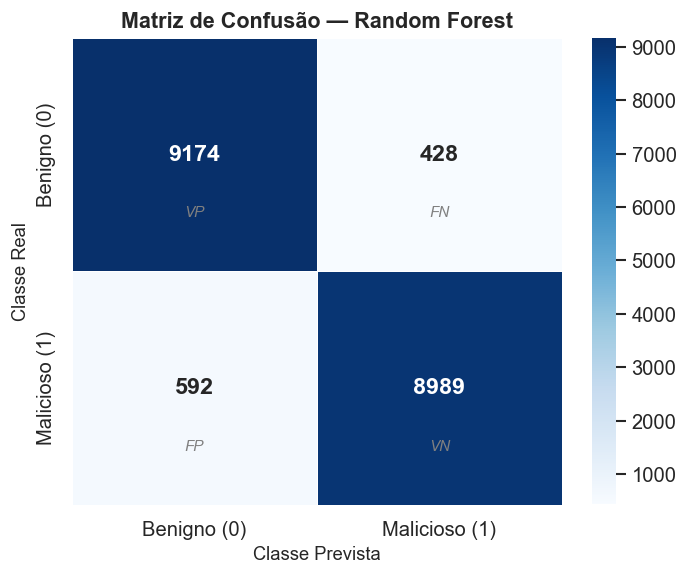

VP (Benignos corretos)   : 9,174
FN (Benignos como malic.): 428
FP (Malic. como benignos): 592
VN (Malic. corretos)     : 8,989


In [6]:
r = resultados['Random Forest']
cm = confusion_matrix(y_test, r['y_pred'])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (0)', 'Malicioso (1)'],
            yticklabels=['Benigno (0)', 'Malicioso (1)'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Classe Prevista', fontsize=11)
ax.set_ylabel('Classe Real', fontsize=11)
ax.set_title('Matriz de Confusão — Random Forest', fontweight='bold', fontsize=13)

labels = [['VP', 'FN'], ['FP', 'VN']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.75, labels[i][j],
                ha='center', va='center', fontsize=9,
                color='grey', style='italic')
plt.tight_layout()
plt.savefig('fig7_matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'VP (Benignos corretos)   : {cm[0,0]:,}')
print(f'FN (Benignos como malic.): {cm[0,1]:,}')
print(f'FP (Malic. como benignos): {cm[1,0]:,}')
print(f'VN (Malic. corretos)     : {cm[1,1]:,}')

### 5.2 Feature Importance

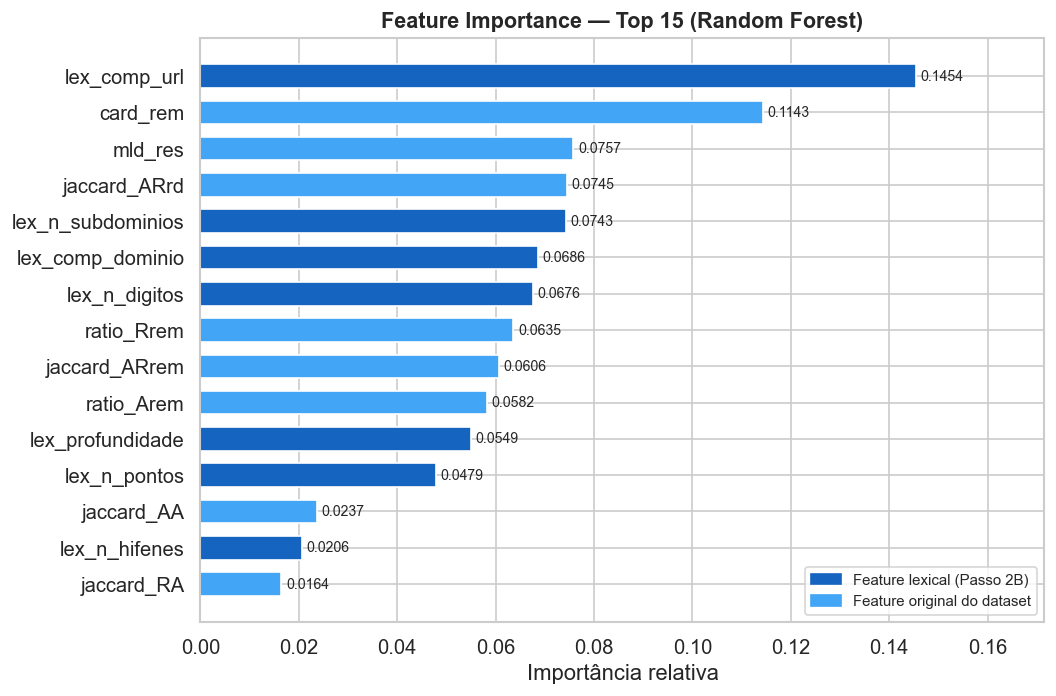

Top 15 features mais importantes:
  lex_comp_url          : 0.1454  ███████████████████████████████████████████
  card_rem              : 0.1143  ██████████████████████████████████
  mld_res               : 0.0757  ██████████████████████
  jaccard_ARrd          : 0.0745  ██████████████████████
  lex_n_subdominios     : 0.0743  ██████████████████████
  lex_comp_dominio      : 0.0686  ████████████████████
  lex_n_digitos         : 0.0676  ████████████████████
  ratio_Rrem            : 0.0635  ███████████████████
  jaccard_ARrem         : 0.0606  ██████████████████
  ratio_Arem            : 0.0582  █████████████████
  lex_profundidade      : 0.0549  ████████████████
  lex_n_pontos          : 0.0479  ██████████████
  jaccard_AA            : 0.0237  ███████
  lex_n_hifenes         : 0.0206  ██████
  jaccard_RA            : 0.0164  ████


In [7]:
rf_model = resultados['Random Forest']['modelo']
importancias = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

top15 = importancias.nlargest(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#1565c0' if 'lex_' in c else '#42a5f5' for c in top15.index]
bars = ax.barh(top15.index, top15.values,
               color=colors, edgecolor='white', height=0.65)
for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

leg1 = mpatches.Patch(color='#1565c0', label='Feature lexical (Passo 2B)')
leg2 = mpatches.Patch(color='#42a5f5', label='Feature original do dataset')
ax.legend(handles=[leg1, leg2], loc='lower right', fontsize=9)
ax.set_title('Feature Importance — Top 15 (Random Forest)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importância relativa')
ax.set_xlim(0, top15.max() * 1.18)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features mais importantes:')
for feat, val in importancias.nlargest(15).items():
    barra = '█' * int(val * 300)
    print(f'  {feat:<22}: {val:.4f}  {barra}')

### 5.3 Curva ROC — Todos os Modelos

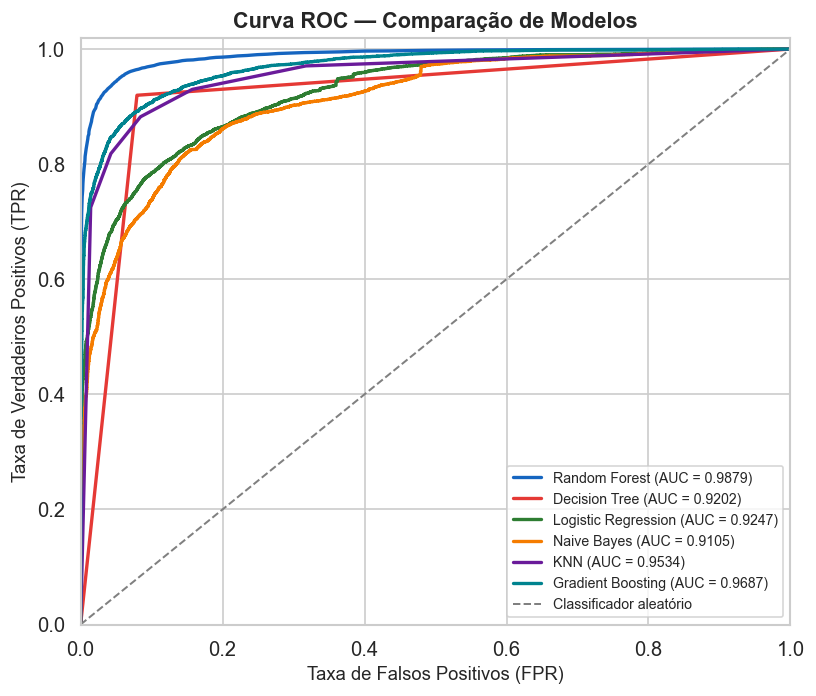

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

cores = ['#1565c0','#e53935','#2e7d32','#f57c00','#6a1b9a','#00838f']

for (nome, r), cor in zip(resultados.items(), cores):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=cor, lw=2,
            label=f"{nome} (AUC = {r['auc']:.4f})")

ax.plot([0,1],[0,1], color='grey', lw=1.2, linestyle='--',
        label='Classificador aleatório')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — Comparação de Modelos',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=8.5)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig9_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Guardar o Melhor Modelo

In [9]:
# Identificar o melhor modelo por F1-Score
melhor_nome = max(resultados, key=lambda k: resultados[k]['f1'])
melhor_modelo = resultados[melhor_nome]['modelo']

print(f'Melhor modelo: {melhor_nome}')
print(f"  F1-Score  : {resultados[melhor_nome]['f1']*100:.2f}%")
print(f"  Accuracy  : {resultados[melhor_nome]['accuracy']*100:.2f}%")

joblib.dump(melhor_modelo, 'modelo_rf.pkl')
print(f'\nModelo guardado: modelo_rf.pkl')

# Verificar
m = joblib.load('modelo_rf.pkl')
print(f'Verificação OK — previsões: {m.predict(X_test[:5]).tolist()}')

Melhor modelo: Random Forest
  F1-Score  : 94.63%
  Accuracy  : 94.68%

Modelo guardado: modelo_rf.pkl
Verificação OK — previsões: [1, 0, 1, 1, 0]


## 7. Resumo

In [10]:
melhor = resultados[melhor_nome]
print('=' * 52)
print('  RESUMO — PASSO 3: TREINO E COMPARAÇÃO')
print('=' * 52)
print(f'  Modelos treinados  : {len(modelos)}')
print(f'  Features           : {X.shape[1]}')
print(f'  Treino/Teste       : 80% / 20%')
print()
print(f'  Melhor modelo      : {melhor_nome}')
print(f"  Accuracy           : {melhor['accuracy']*100:.2f}%")
print(f"  Precision          : {melhor['precision']*100:.2f}%")
print(f"  Recall             : {melhor['recall']*100:.2f}%")
print(f"  F1-Score           : {melhor['f1']*100:.2f}%")
print(f"  AUC-ROC            : {melhor['auc']*100:.2f}%")
print()
print('  Ficheiros gerados  : modelo_rf.pkl')
print('  Gráficos gerados   : fig6_comparacao_modelos.png')
print('                       fig7_matriz_confusao.png')
print('                       fig8_feature_importance.png')
print('                       fig9_curva_roc.png')
print('=' * 52)
print('Próximo passo: Passo 4 — Otimização de Hiperparâmetros')

  RESUMO — PASSO 3: TREINO E COMPARAÇÃO
  Modelos treinados  : 7
  Features           : 21
  Treino/Teste       : 80% / 20%

  Melhor modelo      : Random Forest
  Accuracy           : 94.68%
  Precision          : 95.46%
  Recall             : 93.82%
  F1-Score           : 94.63%
  AUC-ROC            : 98.79%

  Ficheiros gerados  : modelo_rf.pkl
  Gráficos gerados   : fig6_comparacao_modelos.png
                       fig7_matriz_confusao.png
                       fig8_feature_importance.png
                       fig9_curva_roc.png
Próximo passo: Passo 4 — Otimização de Hiperparâmetros
